In [ ]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("file")), "code", "benchmark_networks"))

import numpy as np
import matplotlib.pyplot as plt
import importlib
import data_prepare
importlib.reload(data_prepare)
from data_prepare import prepare_data

# ============================================================
# Load Data
# ============================================================

data_dir = "./data"

EEG = np.load(f"{data_dir}/EEG_all_epochs.npy", allow_pickle=True)
EOG = np.load(f"{data_dir}/EOG_all_epochs.npy", allow_pickle=True)
EMG = np.load(f"{data_dir}/EMG_all_epochs.npy", allow_pickle=True)


# Denoising data after recording

In [2]:
# prepare the data using the provided function
EEG = np.array(EEG.tolist(), dtype=np.float32)
EOG = np.array(EOG.tolist(), dtype=np.float32)
EMG = np.array(EMG.tolist(), dtype=np.float32)

print(f"Originele groottes — EEG: {len(EEG)}, EOG: {len(EOG)}, EMG: {len(EMG)}")

# Afkappen zodat EEG en noise even groot zijn
n_eog = min(len(EEG), len(EOG))
n_emg = min(len(EEG), len(EMG))

# EOG dataset: clean EEG + EOG artefact
noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val, noisy_eog_test, clean_eog_test, std_eog, ref_eog_test = \
    prepare_data(EEG_all=EEG[:n_eog], noise_all=EOG[:n_eog], combin_num=10, train_per=0.8, noise_type='EOG')

# EMG dataset: clean EEG + EMG artefact
noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val, noisy_emg_test, clean_emg_test, std_emg, ref_emg_test = \
    prepare_data(EEG_all=EEG[:n_emg], noise_all=EMG[:n_emg], combin_num=10, train_per=0.8, noise_type='EMG')

print("EOG — train:", noisy_eog_train.shape, "| val:", noisy_eog_val.shape, "| test:", noisy_eog_test.shape)
print("EMG — train:", noisy_emg_train.shape, "| val:", noisy_emg_val.shape, "| test:", noisy_emg_test.shape)

Originele groottes — EEG: 4514, EOG: 3400, EMG: 5598
(27200,)
training data prepared (27200, 512) (27200, 512)
validation data prepared, validation data shape:  (3400, 512) (3400, 512)
test data prepared, test data shape:  (3400, 512) (3400, 512)
(36110,)
training data prepared (36110, 512) (36110, 512)
validation data prepared, validation data shape:  (4520, 512) (4520, 512)
test data prepared, test data shape:  (4510, 512) (4510, 512)
EOG — train: (27200, 512) | val: (3400, 512) | test: (3400, 512)
EMG — train: (36110, 512) | val: (4520, 512) | test: (4510, 512)


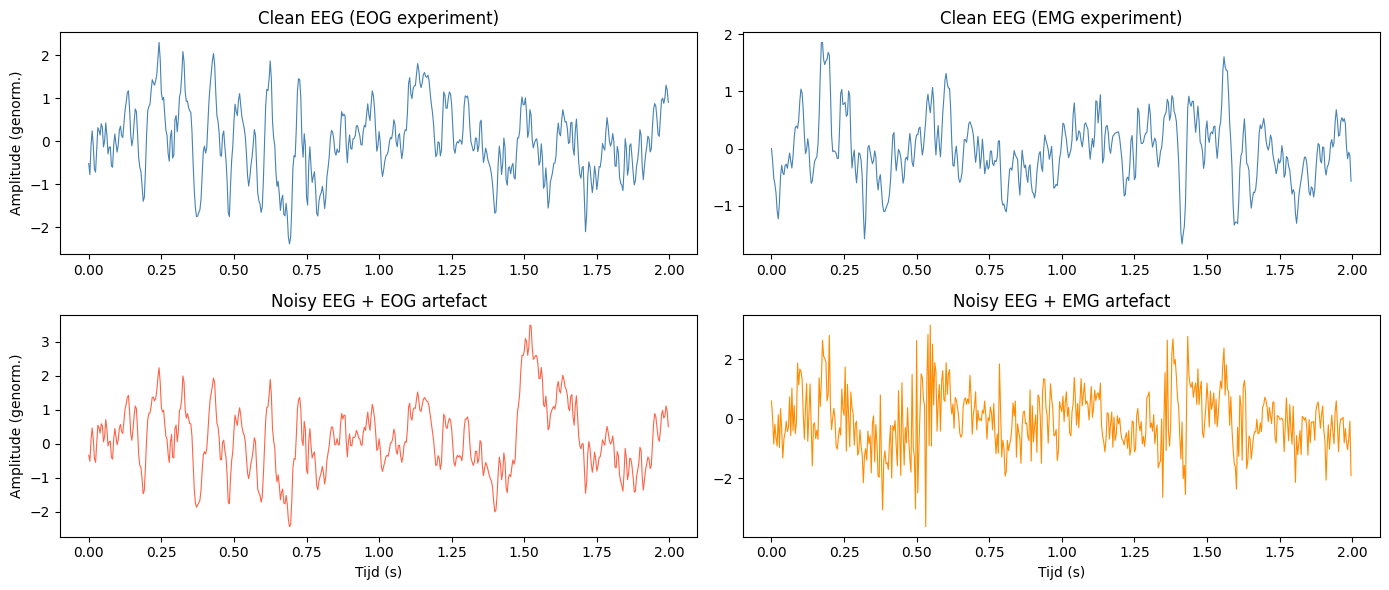

In [3]:
# plot signals
fs = 256
t = np.arange(512) / fs

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# EOG
axes[0, 0].plot(t, clean_eog_train[0], color="steelblue", linewidth=0.8)
axes[0, 0].set_title("Clean EEG (EOG experiment)")
axes[0, 0].set_ylabel("Amplitude (genorm.)")

axes[1, 0].plot(t, noisy_eog_train[0], color="tomato", linewidth=0.8)
axes[1, 0].set_title("Noisy EEG + EOG artefact")
axes[1, 0].set_ylabel("Amplitude (genorm.)")
axes[1, 0].set_xlabel("Tijd (s)")

# EMG
axes[0, 1].plot(t, clean_emg_train[0], color="steelblue", linewidth=0.8)
axes[0, 1].set_title("Clean EEG (EMG experiment)")

axes[1, 1].plot(t, noisy_emg_train[0], color="darkorange", linewidth=0.8)
axes[1, 1].set_title("Noisy EEG + EMG artefact")
axes[1, 1].set_xlabel("Tijd (s)")

plt.tight_layout()
plt.show()

## Code for evaluation


In [4]:
import numpy as np

# uses RRMSE and Pearson Correlation for evaluation
def evaluate(clean, denoised, naam=""):
    rrmse = np.sqrt(np.mean((clean - denoised) ** 2) / np.mean(clean ** 2))
    corr  = np.mean([np.corrcoef(clean[i], denoised[i])[0, 1] for i in range(len(clean))])
    print(f"{naam} — RRMSE: {rrmse:.4f} | Correlatie: {corr:.4f}")


# plot to visualise and compare both signals. Use both test datasets
# example usage:
    # plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
    # plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")

def plot_denoising(clean, denoised, titel="", fs=256, idx=0):
    t = np.arange(clean.shape[1]) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(t, clean[idx],    color="steelblue",  linewidth=0.8, label="Clean EEG")
    plt.plot(t, denoised[idx], color="tomato",      linewidth=0.8, label="Denoised", alpha=0.8)
    plt.title(titel)
    plt.xlabel("Tijd (s)")
    plt.ylabel("Amplitude (genorm.)")
    plt.legend()
    plt.tight_layout()
    plt.show()



## ICA

In [ ]:
from sklearn.decomposition import FastICA
import numpy as np

def ica_denoise(noisy_train, noisy_eval, n_components=32, n_keep=16, fun='logcosh'):
    ica = FastICA(n_components=n_components, random_state=42,
                  max_iter=1000, whiten='unit-variance')
    ica.fit(noisy_train)

    def reconstruct(noisy):
        sources = ica.transform(noisy)
        var      = np.var(sources, axis=0)
        keep_idx = np.argsort(var)[::-1][:n_keep]
        sources_clean = np.zeros_like(sources)
        sources_clean[:, keep_idx] = sources[:, keep_idx]
        return ica.inverse_transform(sources_clean)

    return reconstruct(noisy_eval), ica

### Optuna for hyperparameter tuning

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(noisy_train, noisy_val, clean_val):
    def objective(trial):
        n_components = trial.suggest_int('n_components', 8, 32)
        n_keep       = trial.suggest_int('n_keep', 4, n_components - 1)
        fun          = trial.suggest_categorical('fun', ['logcosh', 'exp', 'cube'])
        denoised_val, _ = ica_denoise(noisy_train, noisy_val, n_components, n_keep, fun)
        return np.sqrt(np.mean((clean_val - denoised_val)**2) / np.mean(clean_val**2))
    return objective


c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


EOG beste params: {'n_components': 16, 'n_keep': 4, 'fun': 'logcosh'}
EOG beste RRMSE:  1.1512753936865276
EMG beste params: {'n_components': 32, 'n_keep': 31, 'fun': 'cube'}
EMG beste RRMSE:  0.8789752637627497
EOG — RRMSE: 1.2206 | Correlatie: 0.1294
EMG — RRMSE: 0.8799 | Correlatie: 0.5734


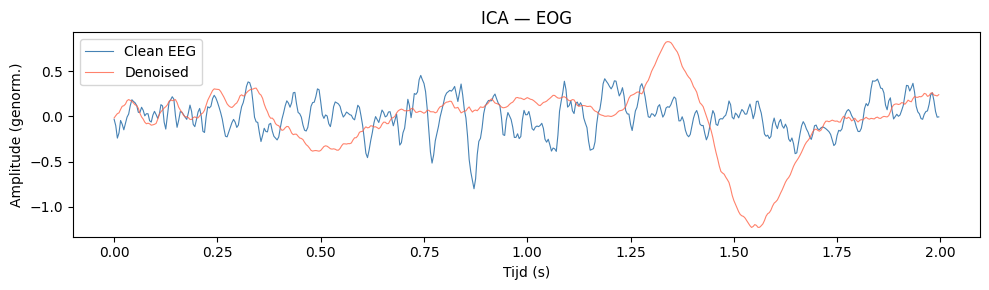

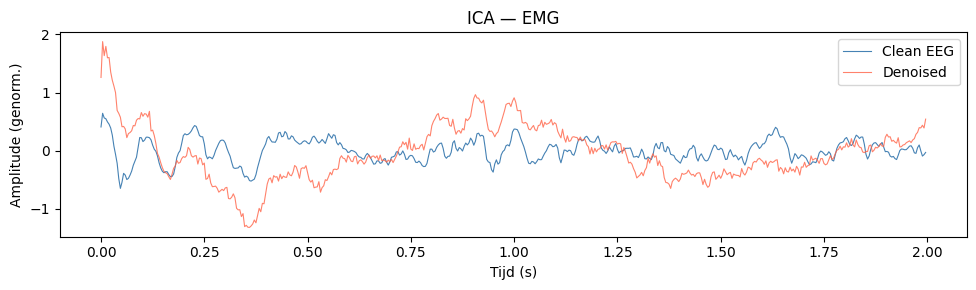

In [ ]:
# start optuna hyperparameter tuning
study_eog = optuna.create_study(direction='minimize')
study_eog.optimize(make_objective(noisy_eog_train, noisy_eog_val, clean_eog_val), n_trials=20)

study_emg = optuna.create_study(direction='minimize')
study_emg.optimize(make_objective(noisy_emg_train, noisy_emg_val, clean_emg_val), n_trials=20)

print("EOG beste params:", study_eog.best_params)
print("EOG beste RRMSE: ", study_eog.best_value)

print("EMG beste params:", study_emg.best_params)
print("EMG beste RRMSE: ", study_emg.best_value)

# train with best hyperparameters and evaluate
denoised_eog_test, _ = ica_denoise(noisy_eog_train, noisy_eog_test, **study_eog.best_params)
evaluate(clean_eog_test, denoised_eog_test, "EOG")

denoised_emg_test, _ = ica_denoise(noisy_emg_train, noisy_emg_test, **study_emg.best_params)
evaluate(clean_emg_test, denoised_emg_test, "EMG")

# plot the results
plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")

### Result

The ICA results are poor for both artifact types. For EOG, the RRMSE of 1.22 indicates the denoised signal is worse than the original noisy signal(RRMSE > 1), and the correlation of 0.13 confirms almost no resemblance to the clean EEG. The plot clearly shows the signals diverge significantly.

For EMG, results are slightly better (RRMSE: 0.88, correlation: 0.57), but still far from acceptable thresholds (RRMSE < 0.3, correlation > 0.95).

The poor performance is expected: ICA is fundamentally designed for multichannel EEG, where it separates sources across electrodes. Applied to single-channel data by treating epochs as channels, it cannot properly identify and isolate artifact components.

##  One-Dimentional Residual Convolutional Neural Network

### create untrained neural network

In [5]:
import torch
import torch.nn as nn

# standard 1D residual block (nn.module to inherit from PyTorch's base class for all NN's)
class ResBlock1D(nn.Module):
    # constructor:
    # - channels: number of datastreams
    # - kernel_size: number of data points "sliding window" looks at at a time
    # - padding: add fake zero's at the edges of the data so "sliding window" doesn't accidently shrink data
    def __init__(self, channels, kernel_size=5, padding=2):
        super(ResBlock1D, self).__init__()
        # initialize convolution (filter): "sliding window" that hunts for noise patterns
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        # initialize batch normalization (stabilizer): scales numbers so they don't get too big/small
        self.bn1 = nn.BatchNorm1d(channels)
        # initialize relu (activator): turn negative numbers into 0, leave positive numbers alone (introduces non-linearity)
        self.relu = nn.ReLU(inplace=True)
        # initialize second convolution
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        # initialize second batch normalization
        self.bn2 = nn.BatchNorm1d(channels)

    # how data moves through the block
    def forward(self, x):
        # save original input
        residual = x

        # pass the data through the layers to isolate the noise
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # add untouched data back into filtered data to restore frequencies the filters might have accidently gotten rid of
        out += residual
        # final activation
        out = self.relu(out)

        return out

# full model:
class ResCNN(nn.Module):
    # constructor:
    # - channel = 1 cause EEG is single-channel
    # - num_features = 64 cause we expand stream into 64 parallel paths
    # - num_blocks = 4 cause 4 residual blocks will be stacked
    def __init__(self, in_channels=1, num_features=64, num_blocks=4):
        super(ResCNN, self).__init__()

        # expands the 1 channel input into 64 feature channels
        self.initial_conv = nn.Conv1d(in_channels, num_features, kernel_size=7, padding=3)
        # stabelize input data
        self.bn_initial = nn.BatchNorm1d(num_features)
        # activate input data
        self.relu = nn.ReLU(inplace=True)

        # creates a sequence of 4 residual blocks and chain them together
        blocks = []
        for _ in range(num_blocks):
            blocks.append(ResBlock1D(channels=num_features))
        self.res_blocks = nn.Sequential(*blocks)

        # compress the 64 feature channels back down to 1 clean EEG channel
        self.final_conv = nn.Conv1d(num_features, in_channels, kernel_size=7, padding=3)

    # how data moves through the model
    def forward(self, x):
        # pass the data through the layers (expands into 64 channels)
        out = self.initial_conv(x)
        out = self.bn_initial(out)
        out = self.relu(out)

        # pass the data through all residual blocks in sequence
        out = self.res_blocks(out)

        # compress data back down to 1 clean EEG channel
        out = self.final_conv(out)
        return out

### reshape data

Neural networks only accept 3D blocks of data, but currently we are working with 2D blocks of data. Therefore, the data has to be repackaged in order for this model to be able to use it.

In [6]:
from torch.utils.data import DataLoader, TensorDataset

# helper function: repackage the numpy arrays into pytorch dataloaders
def make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size):
    # prepare the data from numpy "language" to tensor "language"
    def to_tensor(arr):
        # .unsqueeze(1) takes 2D array and puts "1" in the middle dimension to make it 3D
        return torch.tensor(arr, dtype=torch.float32).unsqueeze(1)

    # package noisy and clean training data together
    train_ds = TensorDataset(to_tensor(noisy_train), to_tensor(clean_train))
    # package noisy and clean validation data together
    val_ds = TensorDataset(to_tensor(noisy_val), to_tensor(clean_val))

    # create the dataloaders (shuffle training data so the model learns better)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds,   batch_size=batch_size)

    return train_loader, val_loader

### train model

In [11]:
# # training function
# def train_rescnn(noisy_train, clean_train, noisy_val, clean_val, num_features=64, num_blocks=4, lr=1e-3, epochs=50, batch_size=256):
#     # reshape the data
#     train_loader, val_loader = make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size)

#     # initialize model
#     model = ResCNN(num_features=num_features, num_blocks=num_blocks)
#     # initialize optimizer (adam is a well-used learning algorithm)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     # create criterion (grades how close the cleaned EEG is to the true EEG, use mean squared error)
#     criterion = nn.MSELoss()

#     # initialize best score
#     best_score = float("inf")
#     # initialize best state (settings when model gets high score)
#     best_state = None

#     print("start training...")

#     # main training loop
#     # for every epoch
#     for epoch in range(epochs):
#         # train the model
#         model.train()
#         # for every batch of noisy+clean training data
#         for noisy_batch, clean_batch in train_loader:
#             # forget previous batch
#             optimizer.zero_grad()

#             # denoise the data by putting noisy data through model
#             denoised_batch = model(noisy_batch)

#             # grader compares model's clean data to actual clean data and grades is (high score = bad)
#             loss = criterion(denoised_batch, clean_batch)

#             # pytorch traces mistakes to figure out which filter caused them
#             loss.backward()
#             # adjust those filters to get better result next batch
#             optimizer.step()

#         # set model to evaluation mode
#         model.eval()
#         # create array with actual clean EEG, create array with model's denoised EEG
#         all_clean, all_denoised = [], []

#         # stop tracking mistakes
#         with torch.no_grad():
#             # for every batch of noisy+clean validation data
#             for noisy_batch, clean_batch in val_loader:
#                 # clean the noisy validation data and convert straight to numpy 2D array
#                 denoised = model(noisy_batch).numpy().squeeze(1)

#                 # append the data to their respective arrays
#                 all_clean.append(clean_batch.numpy().squeeze(1))
#                 all_denoised.append(denoised)

#         # concatenate validation batches back together to calculate final score
#         clean_np = np.concatenate(all_clean)
#         denoised_np = np.concatenate(all_denoised)

#         # calculate RRMSE
#         val_rrmse = np.sqrt(np.mean((clean_np - denoised_np) ** 2) / np.mean(clean_np ** 2))

#         # if this is the best score so far, save the score and a copy of the models settings
#         if val_rrmse < best_score:
#             best_score = val_rrmse
#             best_state = {k: v.clone() for k, v in model.state_dict().items()}

#         # print epoch number and current val RRMSE every 10 epochs
#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch {epoch} | Validation RRMSE: {val_rrmse}")

#     # when training is done, reload best settings we found and return the model and best score
#     model.load_state_dict(best_state)
#     print("Best RRMSE:", best_score)
#     return model, best_score


# # helper function: take noisy numpy array and fully trained model and use model to clean data in array
# def rescnn_denoise(model, noisy_test):
#     # set model to evaluation mode
#     model.eval()
#     # prepare the data for the NN model
#     t = torch.tensor(noisy_test, dtype=torch.float32).unsqueeze(1)
#     # stop tracking mistakes
#     with torch.no_grad():
#         # use model to clean data, turn clean data into 2D numpy array
#         out = model(t).numpy().squeeze(1)
#     return out

# Setup device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# training function
def train_rescnn(noisy_train, clean_train, noisy_val, clean_val, num_features=64, num_blocks=4, lr=1e-3, epochs=50, batch_size=256):
    # reshape the data
    train_loader, val_loader = make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size)

    # initialize model
    model = ResCNN(num_features=num_features, num_blocks=num_blocks).to(device)
    # initialize optimizer (adam is a well-used learning algorithm)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # create criterion (grades how close the cleaned EEG is to the true EEG, use mean squared error)
    criterion = nn.MSELoss()

    # initialize best score
    best_score = float("inf")
    # initialize best state (settings when model gets high score)
    best_state = None

    print("start training...")

    # main training loop
    # for every epoch
    for epoch in range(epochs):
        # train the model
        model.train()
        # for every batch of noisy+clean training data
        for noisy_batch, clean_batch in train_loader:
            # Move batches to device
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)

            # forget previous batch
            optimizer.zero_grad()

            # denoise the data by putting noisy data through model
            denoised_batch = model(noisy_batch)

            # grader compares model's clean data to actual clean data and grades is (high score = bad)
            loss = criterion(denoised_batch, clean_batch)

            # pytorch traces mistakes to figure out which filter caused them
            loss.backward()
            # adjust those filters to get better result next batch
            optimizer.step()

        # set model to evaluation mode
        model.eval()
        # create array with actual clean EEG, create array with model's denoised EEG
        all_clean, all_denoised = [], []

        # stop tracking mistakes
        with torch.no_grad():
            # for every batch of noisy+clean validation data
            for noisy_batch, clean_batch in val_loader:
                # clean the noisy validation data and convert straight to numpy 2D array
                denoised = model(noisy_batch.to(device)).cpu().numpy().squeeze(1)

                # append the data to their respective arrays
                all_clean.append(clean_batch.numpy().squeeze(1))
                all_denoised.append(denoised)

        # concatenate validation batches back together to calculate final score
        clean_np = np.concatenate(all_clean)
        denoised_np = np.concatenate(all_denoised)

        # calculate RRMSE
        val_rrmse = np.sqrt(np.mean((clean_np - denoised_np) ** 2) / np.mean(clean_np ** 2))

        # if this is the best score so far, save the score and a copy of the models settings
        if val_rrmse < best_score:
            best_score = val_rrmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # print epoch number and current val RRMSE every 10 epochs
        if (epoch + 1) % 10 == 0:
          print(f"Epoch {epoch} | Validation RRMSE: {val_rrmse}")

    # when training is done, reload best settings we found and return the model and best score
    model.load_state_dict(best_state)
    print("Best RRMSE:", best_score)
    return model, best_score


# helper function: take noisy numpy array and fully trained model and use model to clean data in array
def rescnn_denoise(model, noisy_test):
    # set model to evaluation mode
    model.eval()
    # prepare the data for the NN model
    t = torch.tensor(noisy_test, dtype=torch.float32).unsqueeze(1).to(device)
    # stop tracking mistakes
    with torch.no_grad():
        # use model to clean data, turn clean data into 2D numpy array
        out = model(t).cpu().numpy().squeeze(1)
    return out

### hyperparameter tuning using optuna

In [12]:
import optuna
def make_rescnn_objective(noisy_train, clean_train, noisy_val, clean_val):
    def objective(trial):
        # optuna randomly picks these settings to find optimal combination
        num_features = trial.suggest_categorical("num_features", [32, 64, 128])
        num_blocks = trial.suggest_int("num_blocks", 2, 8)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

        # train model with Optuna's chosen settings (use 20 epochs to save time)
        _, val_rrmse = train_rescnn(
            noisy_train, clean_train, noisy_val, clean_val,
            num_features=num_features, num_blocks=num_blocks,
            lr=lr, batch_size=batch_size,
            epochs=20
        )

        return val_rrmse

    return objective

# mute optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

# start optuna hyperparameter tuning
study_eog = optuna.create_study(direction="minimize")
study_eog.optimize(make_rescnn_objective(noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val), n_trials=10)

print("EOG best params: ", study_eog.best_params)
print("EOG best RRMSE: ", study_eog.best_value)

study_emg = optuna.create_study(direction="minimize")
study_emg.optimize(make_rescnn_objective(noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val), n_trials=10)

print("EMG best params: ", study_emg.best_params)
print("EMG best RRMSE: ", study_emg.best_value)

start training...
Epoch 9 | Validation RRMSE: 0.48905646800994873
Epoch 19 | Validation RRMSE: 0.4855516254901886
Best RRMSE: 0.48546907
start training...
Epoch 9 | Validation RRMSE: 0.4645383656024933
Epoch 19 | Validation RRMSE: 0.45664796233177185
Best RRMSE: 0.454515
start training...
Epoch 9 | Validation RRMSE: 0.47341498732566833
Epoch 19 | Validation RRMSE: 0.4577457010746002
Best RRMSE: 0.4562173
start training...
Epoch 9 | Validation RRMSE: 0.4575748145580292
Epoch 19 | Validation RRMSE: 0.44174978137016296
Best RRMSE: 0.44174978
start training...
Epoch 9 | Validation RRMSE: 0.46304264664649963
Epoch 19 | Validation RRMSE: 0.44424867630004883
Best RRMSE: 0.44424868
start training...
Epoch 9 | Validation RRMSE: 0.4413607716560364
Epoch 19 | Validation RRMSE: 0.43929868936538696
Best RRMSE: 0.43490407
start training...
Epoch 9 | Validation RRMSE: 0.5170966386795044
Epoch 19 | Validation RRMSE: 0.43988656997680664
Best RRMSE: 0.4397313
start training...
Epoch 9 | Validation RRMSE

### visualizations + result

start training...
Epoch 9 | Validation RRMSE: 0.45055925846099854
Epoch 19 | Validation RRMSE: 0.4312935471534729
Epoch 29 | Validation RRMSE: 0.44698795676231384
Epoch 39 | Validation RRMSE: 0.4281456470489502
Epoch 49 | Validation RRMSE: 0.4192279577255249
Best RRMSE: 0.41904807
ResCNN — EOG — RRMSE: 0.4305 | Correlatie: 0.8803
start training...
Epoch 9 | Validation RRMSE: 0.5636540651321411
Epoch 19 | Validation RRMSE: 0.5537188053131104
Epoch 29 | Validation RRMSE: 0.5554835200309753
Epoch 39 | Validation RRMSE: 0.5713876485824585
Epoch 49 | Validation RRMSE: 0.5930871963500977
Best RRMSE: 0.55171275
ResCNN — EMG — RRMSE: 0.5379 | Correlatie: 0.7665


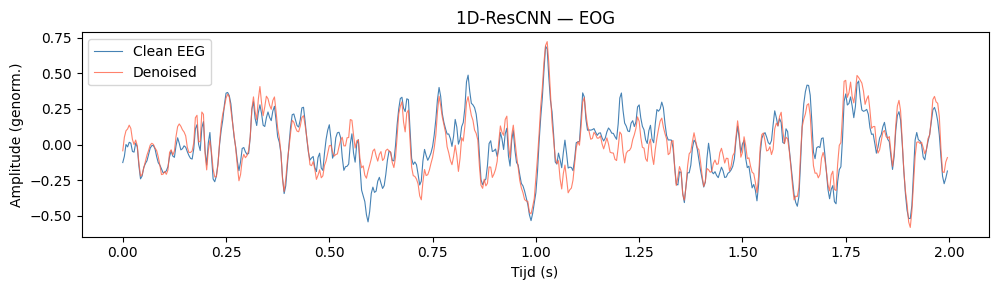

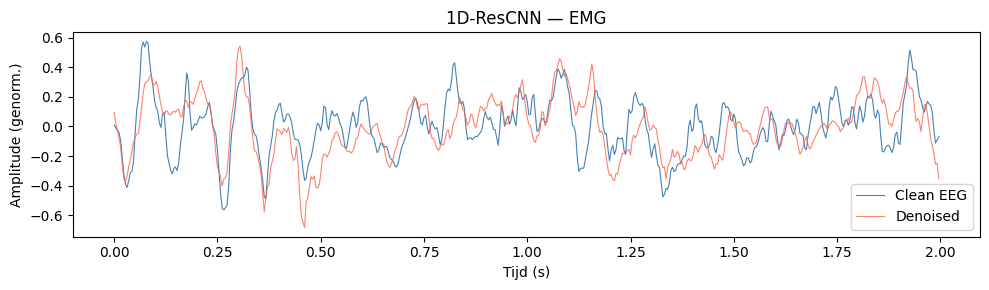

In [13]:
# train a model using the best params Optuna found to clean EOG
final_eog_model, final_eog_rrmse = train_rescnn(
    noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val,
    **study_eog.best_params, epochs=50
)
# let this model clean unseen test data
denoised_eog_test = rescnn_denoise(final_eog_model, noisy_eog_test)
# grade it
evaluate(clean_eog_test, denoised_eog_test, "ResCNN — EOG")

# train a model using the best params Optuna found to clean EMG
final_emg_model, final_emg_rrmse = train_rescnn(
    noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val,
    **study_emg.best_params, epochs=50
)
# let this model clean unseen test data
denoised_emg_test = rescnn_denoise(final_emg_model, noisy_emg_test)
# grade it
evaluate(clean_emg_test, denoised_emg_test, "ResCNN — EMG")


# plot the results
plot_denoising(clean_eog_test, denoised_eog_test, "1D-ResCNN — EOG")
plot_denoising(clean_emg_test, denoised_emg_test, "1D-ResCNN — EMG")

#### RESULT

The 1D-ResCNN shows a strong performance in removing EOG artifacts. With an RRMSE of 0.4305 and a high correlation of 0.8803, the model successfully reconstructs a signal that closely resembles the clean EEG. The plot confirms this, showing the denoised signal accurately tracking the movement of the underlying clean EEG plot without significantly under- or overshooting. This success is to be expected: EOG generates large waveforms that contrast sharply with the faster activity of normal brain waves. Because the shape of an EOG artifact is so distinct and predictable, the neural network can easily identify the pattern and remove it without damaging the real EEG signal underneath.

For EMG artifacts, the model's performance is moderate, having an RRMSE of 0.5379 and a correlation of 0.7665. While the plot shows that the denoised signal successfully captures the general overall movement of the clean EEG, it struggles to perfectly reconstruct the finer fluctuations. This lower accuracy highlights a classic challenge in analyzing EEG data: EMG noise is fast, chaotic, and closely resembles the high-frequency neural activity. Because these two signals overlap so heavily on a single channel, the neural network struggles to tell them apart. To compensate, the model tends to smooth out the data, which explains the lower correlation compared to the easily identifiable EOG.

# Denoising data Real-Time

In [ ]:
import time

# generator function to simulate real-time streaming of EEG data
def realtime_stream(noisy_epochs, ref_epochs, fs=256, simulate_delay=False):
    for ep in range(len(noisy_epochs)):
        for sample_idx in range(noisy_epochs.shape[1]):
            eeg_sample = noisy_epochs[ep, sample_idx]
            ref_sample = ref_epochs[ep, sample_idx]
            if simulate_delay:
                time.sleep(1 / fs)
            yield eeg_sample, ref_sample, ep, sample_idx